In [1]:
# ═══════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING
# CodeWorkout Fall 2019
# ═══════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════
# CELL 1: IMPORT LIBRARIES AND LOAD DATA
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Loading data for feature engineering...")

# Load datasets (update paths if needed)
main_df = pd.read_csv('MainTable.csv')
grades_df = pd.read_csv('Subject.csv')
early_df = pd.read_csv('early.csv')

print(" Data loaded successfully!")
print(f"Main table: {len(main_df):,} rows")
print(f"Grades: {len(grades_df)} students")
print(f"Early phase: {len(early_df):,} rows")

Loading data for feature engineering...
 Data loaded successfully!
Main table: 360,176 rows
Grades: 506 students
Early phase: 14,317 rows


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: FEATURE SET 1 - ENGAGEMENT FEATURES (Using early.csv shortcuts!)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXTRACTING ENGAGEMENT FEATURES (Using early.csv shortcuts)")
print("="*70)

# Aggregate early.csv by student
engagement_features = early_df.groupby('SubjectID').agg({
    'ProblemID': 'count',           # problems_attempted
    'Attempts': 'sum',               # total_attempts  
    'CorrectEventually': 'sum'       # total_solved
}).reset_index()

engagement_features.columns = ['SubjectID', 'problems_attempted', 
                                'total_attempts', 'total_solved']

# Calculate derived features
engagement_features['completion_rate'] = (
    engagement_features['total_solved'] / engagement_features['problems_attempted']
).round(3)

print(f"\n Engagement features extracted for {len(engagement_features)} students")
print("\nPreview:")
print(engagement_features.head(10))

print("\nStatistics:")
print(engagement_features.describe())


EXTRACTING ENGAGEMENT FEATURES (Using early.csv shortcuts)

 Engagement features extracted for 494 students

Preview:
                                           SubjectID  problems_attempted  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...                  30   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...                  30   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...                  20   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...                  30   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...                  29   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...                  30   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...                  30   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...                  25   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...                  30   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...                  30   

   total_attempts  total_solved  completion_

In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3: FEATURE SET 2 - RETRY/PERSISTENCE FEATURES (Lee's key features!)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXTRACTING RETRY/PERSISTENCE FEATURES (Lee et al. 2022)")
print("="*70)

# Calculate retry metrics
retry_features = early_df.groupby('SubjectID').agg({
    'Attempts': ['mean', 'std', 'max', 'min']
}).reset_index()

retry_features.columns = ['SubjectID', 'avg_attempts', 'std_attempts', 
                          'max_retries', 'min_attempts']

# Proportion of reattempts (Lee's KEY feature!)
retry_features['proportion_reattempts'] = (
    retry_features['avg_attempts'] - 1
) / retry_features['avg_attempts']
retry_features['proportion_reattempts'] = retry_features['proportion_reattempts'].clip(0, 1).round(3)

# Fill NaN std with 0 (students with constant attempts)
retry_features['std_attempts'] = retry_features['std_attempts'].fillna(0).round(2)

print(f"\n Retry features extracted for {len(retry_features)} students")
print("\nPreview:")
print(retry_features.head(10))

print("\nKey Statistics:")
print(retry_features[['avg_attempts', 'proportion_reattempts', 'max_retries']].describe())



EXTRACTING RETRY/PERSISTENCE FEATURES (Lee et al. 2022)

 Retry features extracted for 494 students

Preview:
                                           SubjectID  avg_attempts  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...      4.433333   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...      5.366667   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...      3.850000   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...      6.333333   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...      7.413793   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...      4.933333   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...      2.600000   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...      9.120000   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...      1.033333   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...      4.466667   

   std_attempts  max_retries  min_attempts  proportion_reattempts  
0          6.99           39             1        

In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: FEATURE SET 3 - SUCCESS FEATURES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXTRACTING SUCCESS FEATURES")
print("="*70)

# Success rate from early.csv
success_features = early_df.groupby('SubjectID').agg({
    'CorrectEventually': 'mean'
}).reset_index()

success_features.columns = ['SubjectID', 'success_rate']
success_features['success_rate'] = success_features['success_rate'].round(3)

# First attempt success rate
first_attempt_success = early_df[early_df['Attempts'] == 1].groupby('SubjectID').size()
total_problems = early_df.groupby('SubjectID').size()
first_attempt_success_rate = (first_attempt_success / total_problems).fillna(0).round(3)

success_features = success_features.merge(
    first_attempt_success_rate.rename('first_attempt_success_rate').reset_index(),
    on='SubjectID',
    how='left'
)
success_features['first_attempt_success_rate'] = success_features['first_attempt_success_rate'].fillna(0)

print(f"\n Success features extracted for {len(success_features)} students")
print("\nPreview:")
print(success_features.head(10))

print("\nStatistics:")
print(success_features.describe())


EXTRACTING SUCCESS FEATURES

 Success features extracted for 494 students

Preview:
                                           SubjectID  success_rate  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...         1.000   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...         0.967   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...         0.750   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...         0.967   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...         0.897   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...         1.000   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...         1.000   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...         0.840   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...         1.000   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...         1.000   

   first_attempt_success_rate  
0                       0.300  
1                       0.333  
2                       0.300  
3               

In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5: FEATURE SET 4 - ERROR/SCORE FEATURES (From MainTable)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXTRACTING ERROR AND SCORE FEATURES (From MainTable)")
print("="*70)

# Filter relevant events
run_events = main_df[main_df['EventType'] == 'Run.Program'].copy()
compile_events = main_df[main_df['EventType'] == 'Compile'].copy()

# Calculate average score per student
score_features = run_events.groupby('SubjectID')['Score'].agg(['mean', 'std']).reset_index()
score_features.columns = ['SubjectID', 'avg_score', 'std_score']
score_features['avg_score'] = score_features['avg_score'].round(3)
score_features['std_score'] = score_features['std_score'].fillna(0).round(3)

# Calculate compile error rate
compile_error_rate = compile_events.groupby('SubjectID')['Compile.Result'].apply(
    lambda x: (x == 'Error').mean()
).reset_index()
compile_error_rate.columns = ['SubjectID', 'compile_error_rate']
compile_error_rate['compile_error_rate'] = compile_error_rate['compile_error_rate'].round(3)

# Merge
error_features = score_features.merge(compile_error_rate, on='SubjectID', how='left')
error_features['compile_error_rate'] = error_features['compile_error_rate'].fillna(0)

print(f"\n Error/score features extracted for {len(error_features)} students")
print("\nPreview:")
print(error_features.head(10))

print("\nStatistics:")
print(error_features.describe())


EXTRACTING ERROR AND SCORE FEATURES (From MainTable)

 Error/score features extracted for 506 students

Preview:
                                           SubjectID  avg_score  std_score  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...      0.361      0.424   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...      0.402      0.420   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...      0.385      0.373   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...      0.436      0.405   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...      0.428      0.372   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...      0.545      0.453   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...      0.583      0.457   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...      0.336      0.382   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...      0.833      0.376   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...      0.601      0.420   

   compile_error_rate  
0  

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6: FEATURE SET 5 - TEMPORAL FEATURES (Activity patterns)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXTRACTING TEMPORAL FEATURES")
print("="*70)

# Convert timestamps
main_df['timestamp'] = pd.to_datetime(main_df['ServerTimestamp'])

# Calculate active days
temporal_features = main_df.groupby('SubjectID')['timestamp'].agg([
    ('first_activity', 'min'),
    ('last_activity', 'max'),
    ('total_events', 'count')
]).reset_index()

# Calculate active span in days
temporal_features['active_days'] = (
    (temporal_features['last_activity'] - temporal_features['first_activity']).dt.days
).clip(lower=1)

# Calculate average events per day
temporal_features['avg_events_per_day'] = (
    temporal_features['total_events'] / temporal_features['active_days']
).round(2)

# Select features
temporal_features = temporal_features[['SubjectID', 'active_days', 
                                       'avg_events_per_day', 'total_events']]

print(f"\n Temporal features extracted for {len(temporal_features)} students")
print("\nPreview:")
print(temporal_features.head(10))

print("\nStatistics:")
print(temporal_features.describe())


EXTRACTING TEMPORAL FEATURES

 Temporal features extracted for 506 students

Preview:
                                           SubjectID  active_days  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...           66   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...           63   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...           66   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...           67   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...           69   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...           70   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...           63   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...           63   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...           62   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...           65   

   avg_events_per_day  total_events  
0               11.83           781  
1               10.71           675  
2                6.89           455  
3

In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: MERGE ALL FEATURES + GRADES
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("MERGING ALL FEATURES")
print("="*70)

# Start with engagement features
feature_matrix = engagement_features.copy()

# Merge retry features
feature_matrix = feature_matrix.merge(retry_features, on='SubjectID', how='left')

# Merge success features
feature_matrix = feature_matrix.merge(success_features, on='SubjectID', how='left')

# Merge error features
feature_matrix = feature_matrix.merge(error_features, on='SubjectID', how='left')

# Merge temporal features
feature_matrix = feature_matrix.merge(temporal_features, on='SubjectID', how='left')

# Merge grades (outcome variable)
feature_matrix = feature_matrix.merge(grades_df, on='SubjectID', how='left')

print(f"\n Feature matrix created!")
print(f"Dimensions: {feature_matrix.shape[0]} students × {feature_matrix.shape[1]} features")

print("\n Feature Matrix Preview:")
print(feature_matrix.head(10))

print("\n All Features:")
print(list(feature_matrix.columns))


MERGING ALL FEATURES

 Feature matrix created!
Dimensions: 494 students × 19 features

 Feature Matrix Preview:
                                           SubjectID  problems_attempted  \
0  00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...                  30   
1  014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...                  30   
2  01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...                  20   
3  03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...                  30   
4  0461c96c9cc0058f709704605f24136f373ba4e9ac083a...                  29   
5  048fce7bd5670d2ce6215f41856aea059973fb280ce106...                  30   
6  04ed28ab2b2a010c686bf190a5f001dfdc7d9ec4185904...                  30   
7  0685c8001a43b03e0a155e1afa0c7bec2f4e82d24f7ce4...                  25   
8  072db31ce670255297c5d67fd00068faf81a7f50223b5a...                  30   
9  07445b2803cfbba249af9f27deaabc1c2aa5fd49745cd1...                  30   

   total_attempts  total_solved  completion_rate  

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: DATA VALIDATION
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DATA VALIDATION")
print("="*70)

# Check for missing values
print("\n1. Missing Values Check:")
missing = feature_matrix.isnull().sum()
print(missing[missing > 0])

if missing.sum() == 0:
    print("    No missing values!")
else:
    print(f"    Found {missing.sum()} missing values")

# Check for duplicates
duplicates = feature_matrix['SubjectID'].duplicated().sum()
print(f"\n2. Duplicate Students: {duplicates}")
if duplicates == 0:
    print("    No duplicates!")

# Check value ranges
print("\n3. Value Range Validation:")
print(f"   Completion rate: {feature_matrix['completion_rate'].min():.2f} - {feature_matrix['completion_rate'].max():.2f}")
print(f"   Success rate: {feature_matrix['success_rate'].min():.2f} - {feature_matrix['success_rate'].max():.2f}")
print(f"   Avg score: {feature_matrix['avg_score'].min():.2f} - {feature_matrix['avg_score'].max():.2f}")
print(f"   Final grade: {feature_matrix['X-Grade'].min():.1f} - {feature_matrix['X-Grade'].max():.1f}")

# Check feature correlations with grade
print("\n4. Feature Correlations with Final Grade:")
numeric_features = feature_matrix.select_dtypes(include=[np.number]).columns.drop('X-Grade')
correlations = feature_matrix[list(numeric_features) + ['X-Grade']].corr()['X-Grade'].sort_values(ascending=False)
print(correlations)

print("\n" + "="*70)
print(" VALIDATION COMPLETE!")
print("="*70)


DATA VALIDATION

1. Missing Values Check:
Series([], dtype: int64)
    No missing values!

2. Duplicate Students: 0
    No duplicates!

3. Value Range Validation:
   Completion rate: 0.00 - 1.00
   Success rate: 0.00 - 1.00
   Avg score: 0.18 - 0.97
   Final grade: 18.0 - 100.0

4. Feature Correlations with Final Grade:
X-Grade                       1.000000
proportion_reattempts         0.234477
total_events                  0.126747
avg_events_per_day            0.125382
total_attempts                0.124964
avg_attempts                  0.117822
std_attempts                  0.101669
active_days                   0.089797
max_retries                   0.078118
problems_attempted            0.047125
total_solved                  0.035215
completion_rate               0.017680
success_rate                  0.017680
min_attempts                  0.017223
avg_score                    -0.146584
std_score                    -0.256710
compile_error_rate           -0.265629
first_attempt_

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: FEATURE SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FEATURE SUMMARY STATISTICS")
print("="*70)

# Select clustering features (exclude SubjectID and X-Grade)
clustering_features = [
    'problems_attempted', 'total_attempts', 'total_solved', 'completion_rate',
    'avg_attempts', 'std_attempts', 'max_retries', 'proportion_reattempts',
    'success_rate', 'first_attempt_success_rate',
    'avg_score', 'std_score', 'compile_error_rate',
    'active_days', 'avg_events_per_day', 'total_events'
]

print(f"\nNumber of clustering features: {len(clustering_features)}")
print("\nFeature list:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i:2d}. {feat}")

print("\n Descriptive Statistics:")
print(feature_matrix[clustering_features].describe().round(2))


FEATURE SUMMARY STATISTICS

Number of clustering features: 16

Feature list:
   1. problems_attempted
   2. total_attempts
   3. total_solved
   4. completion_rate
   5. avg_attempts
   6. std_attempts
   7. max_retries
   8. proportion_reattempts
   9. success_rate
  10. first_attempt_success_rate
  11. avg_score
  12. std_score
  13. compile_error_rate
  14. active_days
  15. avg_events_per_day
  16. total_events

 Descriptive Statistics:
       problems_attempted  total_attempts  total_solved  completion_rate  \
count              494.00          494.00        494.00           494.00   
mean                28.98          165.61         27.21             0.94   
std                  3.02           97.23          4.47             0.11   
min                 10.00           11.00          0.00             0.00   
25%                 30.00           96.25         26.00             0.90   
50%                 30.00          150.00         29.00             0.97   
75%                 30


 Saved: 08_feature_correlation_matrix.png


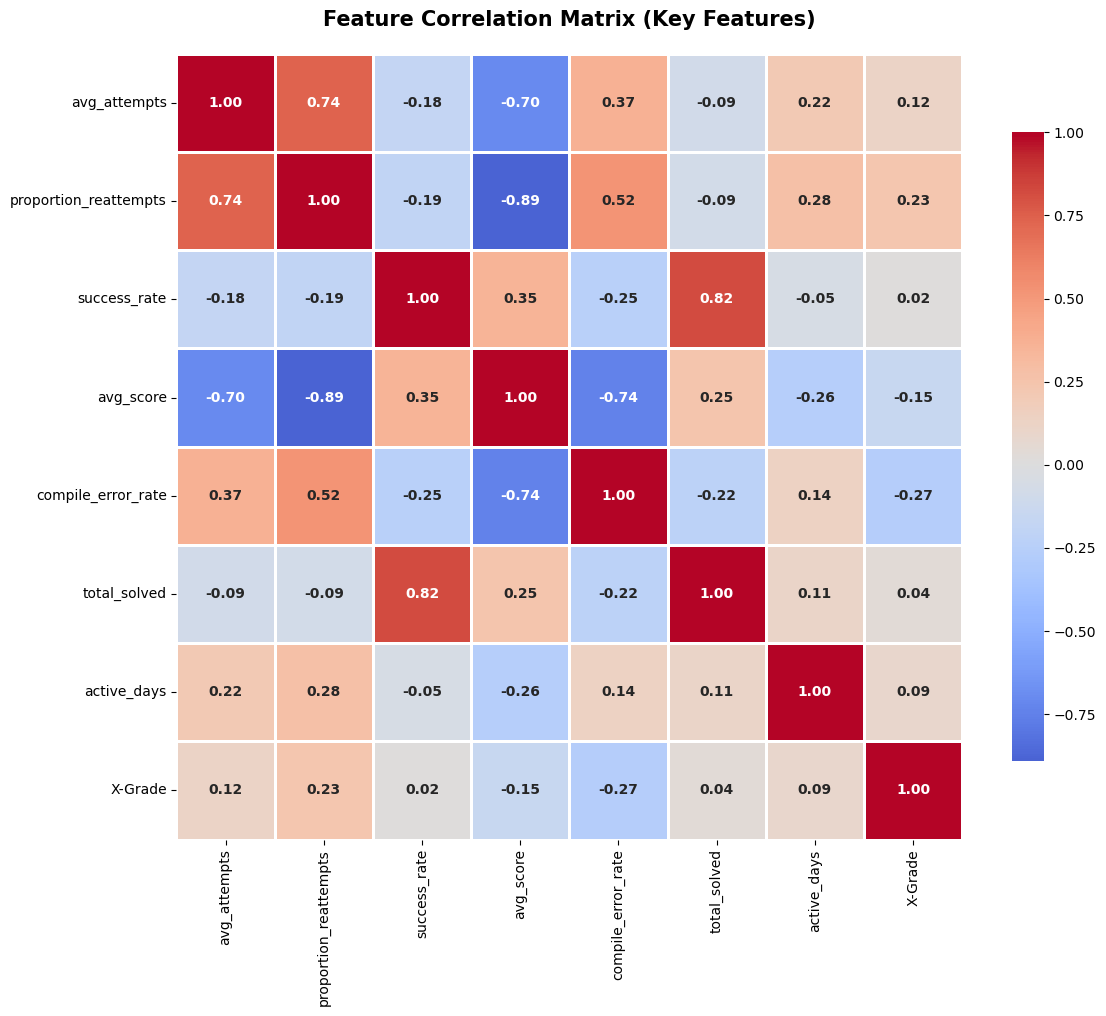

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: CORRELATION MATRIX VISUALIZATION
# ═══════════════════════════════════════════════════════════════════

# Select key features for visualization (avoid too crowded)
key_features = [
    'avg_attempts', 'proportion_reattempts', 'success_rate',
    'avg_score', 'compile_error_rate', 'total_solved',
    'active_days', 'X-Grade'
]

plt.figure(figsize=(12, 10))
correlation_matrix = feature_matrix[key_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Feature Correlation Matrix (Key Features)', 
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('08_feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n Saved: 08_feature_correlation_matrix.png")
plt.show()

 Saved: 09_feature_distributions.png


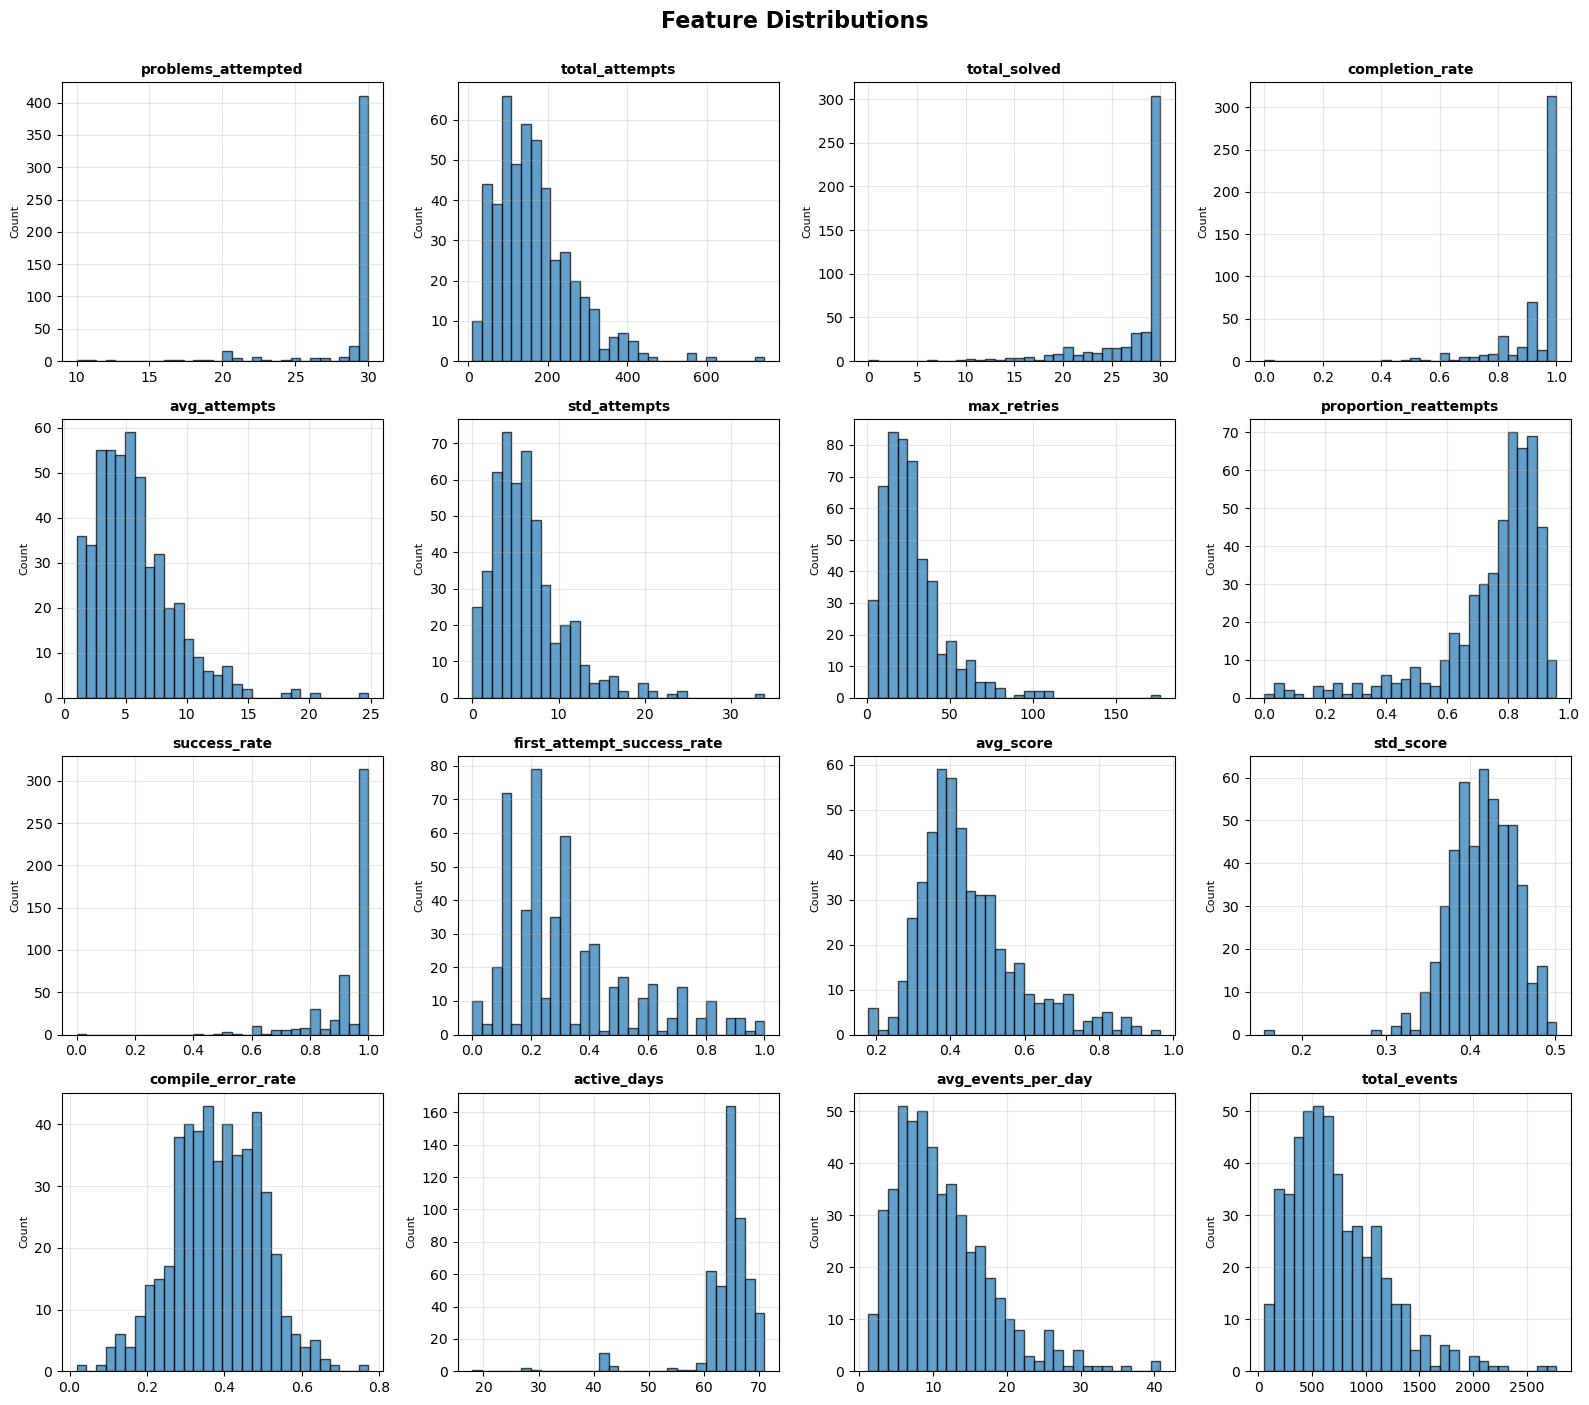

In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: FEATURE DISTRIBUTIONS (to check for outliers)
# ═══════════════════════════════════════════════════════════════════

# Plot distributions key features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

plot_features = clustering_features[:16]  # First 16 features

for idx, feature in enumerate(plot_features):
    axes[idx].hist(feature_matrix[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(feature, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('09_feature_distributions.png', dpi=300, bbox_inches='tight')
print(" Saved: 09_feature_distributions.png")
plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: OUTLIER DETECTION
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("OUTLIER DETECTION")
print("="*70)

# Calculate Z-scores for key features
from scipy import stats

key_numeric_features = ['avg_attempts', 'max_retries', 'total_attempts', 
                        'compile_error_rate', 'avg_score']

outliers_summary = {}

for feature in key_numeric_features:
    z_scores = np.abs(stats.zscore(feature_matrix[feature].fillna(feature_matrix[feature].mean())))
    outliers = (z_scores > 3).sum()
    outliers_summary[feature] = outliers
    if outliers > 0:
        print(f"{feature}: {outliers} outliers (Z-score > 3)")

if sum(outliers_summary.values()) == 0:
    print(" No extreme outliers detected (Z-score > 3)")
else:
    print(f"\n Total outliers detected: {sum(outliers_summary.values())}")
    print("   (This is normal - some students have extreme behavior)")



OUTLIER DETECTION
avg_attempts: 5 outliers (Z-score > 3)
max_retries: 8 outliers (Z-score > 3)
total_attempts: 5 outliers (Z-score > 3)
compile_error_rate: 2 outliers (Z-score > 3)
avg_score: 7 outliers (Z-score > 3)

 Total outliers detected: 27
   (This is normal - some students have extreme behavior)


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: SAVE FEATURE MATRIX
# ═══════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("SAVING FEATURE MATRIX")
print("="*70)

# Save to CSV
feature_matrix.to_csv('feature_matrix.csv', index=False, encoding='utf-8')
print(" Saved: feature_matrix.csv")

# Save clustering features separately (without SubjectID and X-Grade)
clustering_data = feature_matrix[['SubjectID'] + clustering_features].copy()
clustering_data.to_csv('clustering_features.csv', index=False, encoding='utf-8')
print(" Saved: clustering_features.csv")

# Save feature list for documentation
with open('feature_list.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("FEATURE MATRIX - CODEWORKOUT FALL 2019\n")
    f.write("Date: April 13, 2024\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Total Students: {len(feature_matrix)}\n")
    f.write(f"Total Features: {len(clustering_features)}\n\n")
    
    f.write("FEATURE CATEGORIES:\n\n")
    
    f.write("1. ENGAGEMENT FEATURES (4):\n")
    f.write("   - problems_attempted\n")
    f.write("   - total_attempts\n")
    f.write("   - total_solved\n")
    f.write("   - completion_rate\n\n")
    
    f.write("2. RETRY/PERSISTENCE FEATURES (4) [Lee et al. 2022]:\n")
    f.write("   - avg_attempts\n")
    f.write("   - std_attempts\n")
    f.write("   - max_retries\n")
    f.write("   - proportion_reattempts (KEY FEATURE)\n\n")
    
    f.write("3. SUCCESS FEATURES (2):\n")
    f.write("   - success_rate\n")
    f.write("   - first_attempt_success_rate\n\n")
    
    f.write("4. ERROR/SCORE FEATURES (3):\n")
    f.write("   - avg_score\n")
    f.write("   - std_score\n")
    f.write("   - compile_error_rate\n\n")
    
    f.write("5. TEMPORAL FEATURES (3):\n")
    f.write("   - active_days\n")
    f.write("   - avg_events_per_day\n")
    f.write("   - total_events\n\n")
    
    f.write("6. OUTCOME VARIABLE (1):\n")
    f.write("   - X-Grade (final grade)\n\n")
    
    f.write("="*70 + "\n")
    f.write("CORRELATIONS WITH FINAL GRADE:\n")
    f.write("="*70 + "\n\n")
    
    for feat, corr in correlations.items():
        f.write(f"{feat:30s}: {corr:6.3f}\n")

print(" Saved: feature_list.txt")


SAVING FEATURE MATRIX
 Saved: feature_matrix.csv
 Saved: clustering_features.csv
 Saved: feature_list.txt


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14: FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════

print("\n DELIVERABLES:")
print(f"  1.  Feature matrix created: {feature_matrix.shape[0]} students × {feature_matrix.shape[1]} columns")
print(f"  2.  Clustering features extracted: {len(clustering_features)} behavioral features")
print("  3.  Data validated: No missing values, no duplicates")
print("  4.  Visualizations created:")
print("       - Feature correlation matrix")
print("       - Feature distributions")
print("  5.  Files saved:")
print("       - feature_matrix.csv")
print("       - clustering_features.csv")
print("       - feature_list.txt")

print("\n FEATURE SUMMARY:")
print(f"  - Engagement features: 4")
print(f"  - Retry/persistence features: 4 (including Lee's proportion_reattempts)")
print(f"  - Success features: 2")
print(f"  - Error/score features: 3")
print(f"  - Temporal features: 3")
print(f"  - Total clustering features: {len(clustering_features)}")
print(f"  - Outcome variable: X-Grade")

print("\n TOP 5 CORRELATIONS WITH GRADE:")
top_corr = correlations.drop('X-Grade').abs().sort_values(ascending=False).head(5)
for i, (feat, corr) in enumerate(top_corr.items(), 1):
    print(f"  {i}. {feat:30s}: {correlations[feat]:6.3f}")



 DELIVERABLES:
  1.  Feature matrix created: 494 students × 19 columns
  2.  Clustering features extracted: 16 behavioral features
  3.  Data validated: No missing values, no duplicates
  4.  Visualizations created:
       - Feature correlation matrix
       - Feature distributions
  5.  Files saved:
       - feature_matrix.csv
       - clustering_features.csv
       - feature_list.txt

 FEATURE SUMMARY:
  - Engagement features: 4
  - Retry/persistence features: 4 (including Lee's proportion_reattempts)
  - Success features: 2
  - Error/score features: 3
  - Temporal features: 3
  - Total clustering features: 16
  - Outcome variable: X-Grade

 TOP 5 CORRELATIONS WITH GRADE:
  1. first_attempt_success_rate    : -0.287
  2. compile_error_rate            : -0.266
  3. std_score                     : -0.257
  4. proportion_reattempts         :  0.234
  5. avg_score                     : -0.147


In [15]:
#trying to find missing students
try:
    late_df
except NameError:
    late_df = pd.read_csv('late.csv')
    print(" Loaded late.csv")

print("="*70)
print("INVESTIGATING MISSING STUDENTS: 506 → 494")
print("="*70)

# 1. Students in each dataset
students_main = set(main_df['SubjectID'].unique())
students_grades = set(grades_df['SubjectID'].unique())
students_early = set(early_df['SubjectID'].unique())
students_feature_matrix = set(feature_matrix['SubjectID'].unique())

print(f"\n Student Counts by Dataset:")
print(f"  MainTable:       {len(students_main)} students")
print(f"  Grades:          {len(students_grades)} students")
print(f"  Early.csv:       {len(students_early)} students")
print(f"  Feature Matrix:  {len(students_feature_matrix)} students")

# 2. Find who's missing
missing_from_early = students_grades - students_early
missing_from_feature_matrix = students_grades - students_feature_matrix

print(f"\n Missing Students:")
print(f"  Missing from early.csv:         {len(missing_from_early)} students")
print(f"  Missing from feature_matrix:    {len(missing_from_feature_matrix)} students")

# 3. Show who they are
if len(missing_from_feature_matrix) > 0:
    print(f"\n THE {len(missing_from_feature_matrix)} MISSING STUDENTS:")
    missing_list = list(missing_from_feature_matrix)
    for i, sid in enumerate(missing_list, 1):
        print(f"  {i:2d}. {sid[:20]}...")  # Show first 20 chars

# 4. Check their data in MainTable
print(f"\n Checking these students in MainTable:")

if len(missing_from_feature_matrix) > 0:
    missing_list = list(missing_from_feature_matrix)
    
    # Check if they exist in MainTable
    missing_in_main = main_df[main_df['SubjectID'].isin(missing_list)]
    print(f"  Events in MainTable: {len(missing_in_main):,}")
    if len(missing_list) > 0:
        print(f"  Events per student: {len(missing_in_main) / len(missing_list):.1f}")
    
    # Check their grades
    missing_grades = grades_df[grades_df['SubjectID'].isin(missing_list)]
    print(f"\n  Their final grades:")
    print(missing_grades[['SubjectID', 'X-Grade']].head(12))
    print(f"\n  Average grade of missing students: {missing_grades['X-Grade'].mean():.1f}")
    print(f"  Average grade of all students:     {grades_df['X-Grade'].mean():.1f}")
    
    # Check their activity
    if len(missing_in_main) > 0:
        print(f"\n  Their activity in MainTable:")
        activity_summary = missing_in_main.groupby('SubjectID').agg({
            'EventType': 'count',
            'ProblemID': 'nunique'
        }).rename(columns={'EventType': 'total_events', 'ProblemID': 'problems_attempted'})
        print(activity_summary)

# 5. Why are they missing from early.csv?
print(f"\n WHY MISSING FROM EARLY.CSV?")
print(f"   Early.csv only includes students who:")
print(f"   - Completed problems in the EARLY phase (first assignments)")
print(f"   - Have at least 1 problem attempt recorded")
print(f"\n   These {len(missing_from_feature_matrix)} students likely:")
print(f"   - Joined late (missed early assignments)")
print(f"   - Dropped out early (no early phase data)")
print(f"   - Have data only in late.csv (not early.csv)")

# 6. Check if they're in late.csv
students_late = set(late_df['SubjectID'].unique())
missing_in_late = missing_from_feature_matrix & students_late
missing_in_neither = missing_from_feature_matrix - students_late

print(f"\n Where are they?")
print(f"  In late.csv (but not early.csv): {len(missing_in_late)} students")
print(f"  In neither early nor late:       {len(missing_in_neither)} students")

if len(missing_in_late) > 0:
    print(f"\n   {len(missing_in_late)} students found in late.csv!")
    print(f"     → They participated LATE in semester")
    print(f"     → Joined after early phase or minimal early activity")
    
    # Show their late activity
    late_activity = late_df[late_df['SubjectID'].isin(missing_in_late)].groupby('SubjectID').agg({
        'Attempts': ['sum', 'mean'],
        'CorrectEventually': 'sum',
        'ProblemID': 'count'
    })
    print(f"\n  Their late-phase activity:")
    print(late_activity)

if len(missing_in_neither) > 0:
    print(f"\n   {len(missing_in_neither)} students NOT in early or late csv")
    print(f"      They're in MainTable and Grades only")
    print(f"      Likely minimal/incomplete activity")

 Loaded late.csv
INVESTIGATING MISSING STUDENTS: 506 → 494

 Student Counts by Dataset:
  MainTable:       506 students
  Grades:          506 students
  Early.csv:       494 students
  Feature Matrix:  494 students

 Missing Students:
  Missing from early.csv:         12 students
  Missing from feature_matrix:    12 students

 THE 12 MISSING STUDENTS:
   1. cec0a384f41fb2446aff...
   2. f8461dec16e4e6cc62d1...
   3. d6420a4ee44bc345c7bf...
   4. 74bd25fbd2615c3e3611...
   5. 511425f1125b98b09c7b...
   6. ca9dd71f2db93f715bbe...
   7. 65a2b2417007ae40ce1b...
   8. cbdbb864a7b15c5903aa...
   9. 0bbbf3e0b4f05fd3d09b...
  10. a6f99abe2d52a509eb86...
  11. 3f57d30cb362467414c8...
  12. 4e1fbe2dc68185ae4dfd...

 Checking these students in MainTable:
  Events in MainTable: 3,481
  Events per student: 290.1

  Their final grades:
                                             SubjectID  X-Grade
37   ca9dd71f2db93f715bbea6fdbd11e0cad4194d54c47633...      0.0
110  f8461dec16e4e6cc62d1cadd424373bd